# Домашнее задание 5. Градиентный спуск. (10 баллов + 2 балла бонус)

В этом домашнем задании вы реализуете градиентный спуск для линейной регрессии, а также изучите, как он ведёт себя при разных параметрах и с разными функциями потерь.

Правила:

* Можно использовать без доказательства любые результаты, встречавшиеся на лекциях или семинарах по курсу, если получение этих результатов не является вопросом задания.

* Можно использовать любые свободные источники с *обязательным* указанием ссылки на них.

* Плагиат не допускается. При обнаружении случаев списывания всем участникам нарушения будет выставлено 0 баллов, независимо от того, кто у кого списывал.

* Старайтесь сделать код максимально оптимальным. В частности, будет штрафоваться использование циклов в тех случаях, когда операцию можно совершить при помощи инструментов библиотек, рассмотренных в курсе.  

In [6]:
from typing import Iterable, List

import matplotlib.pyplot as plt
import numpy as np

## Часть 1. Градиентный спуск (5 баллов)

Для начала давайте вспомним самый простой функционал ошибки, который мы применяем в задаче регрессии — **Mean Squared Error (MSE)**:

$$
Q(w, X, y) = \frac{1}{\ell} \sum\limits_{i=1}^\ell (\langle x_i, w \rangle - y_i)^2
$$

где $x_i$ — это $i$-ый объект датасета, $y_i$ — правильный ответ для $i$-го объекта, а $w$ — веса нашей линейной модели.

Как мы помним, для линейной модели его можно записать в матричном виде вот так:

$$
Q(w, X, y) = \frac{1}{\ell} || Xw - y ||^2
$$

где $X$ — это матрица объекты-признаки, а $y$ — вектор правильных ответов.

Чтобы воспользоваться методом градиентного спуска, нам нужно посчитать градиент нашего функционала. Для MSE он будет выглядеть так:

$$
\nabla_w Q(w, X, y) = \frac{2}{\ell} X^T(Xw-y)
$$

Ниже приведён базовый класс `BaseLoss`, который мы будем использовать для реализации всех наших лоссов. Менять его **не нужно**. У него есть два абстрактных метода:
1. Метод `calc_loss`, который будет принимать на вход объекты `x`, правильные ответы `y` и веса `w` и вычислять значения лосса.
2. Метод `calc_grad`, который будет принимать на вход объекты `x`, правильные ответы `y` и веса `w` и вычислять градиент функции потерь по параметрам модели.

In [7]:
import abc


class BaseLoss(abc.ABC):
    """Базовый класс лосса"""

    @abc.abstractmethod
    def calc_loss(self, X: np.ndarray, y: np.ndarray, w: np.ndarray) -> float:
        """
        Функция для вычислений значения лосса
        :param X: np.ndarray размера (n_objects, n_features) с объектами датасета
        :param y: np.ndarray размера (n_objects,) с правильными ответами
        :param w: np.ndarray размера (n_features,) с весами линейной регрессии
        :return: число - значения функции потерь
        """
        raise NotImplementedError

    @abc.abstractmethod
    def calc_grad(self, X: np.ndarray, y: np.ndarray, w: np.ndarray) -> np.ndarray:
        """
        Функция для вычислений градиента лосса по весам w
        :param X: np.ndarray размера (n_objects, n_features) с объектами датасета
        :param y: np.ndarray размера (n_objects,) с правильными ответами
        :param w: np.ndarray размера (n_features,) с весами линейной регрессии
        :return: np.ndarray размера (n_features,) градиент функции потерь по весам w
        """
        raise NotImplementedError

Теперь давайте напишем реализацию этого абстрактного класса: Mean Squared Error лосс.

**Задание 1.1 (5/8 балла):** Реализуйте класс `MSELoss`.

Он должен вычислять лосс и градиент по формулам наверху.

In [8]:
class MSELoss(BaseLoss):
    def calc_loss(self, X: np.ndarray, y: np.ndarray, w: np.ndarray) -> float:
        """
        Функция для вычислений значения лосса
        :param X: np.ndarray размера (n_objects, n_features) с объектами датасета
        :param y: np.ndarray размера (n_objects,) с правильными ответами
        :param w: np.ndarray размера (n_features,) с весами линейной регрессии
        :return: число -- значения функции потерь
        """
        l = len(y)
        return np.linalg.norm(X@ w - y)**2/l

    def calc_grad(self, X: np.ndarray, y: np.ndarray, w: np.ndarray) -> np.ndarray:
        """
        Функция для вычислений градиента лосса по весам w
        :param X: np.ndarray размера (n_objects, n_features) с объектами датасета
        :param y: np.ndarray размера (n_objects,) с правильными ответами
        :param w: np.ndarray размера (n_features,) с весами линейной регрессии
        :return: np.ndarray размера (n_features,) градиент функции потерь по весам w
        """
        l = len(y)
        return 2* X.T @ (X@ w - y) / l

Теперь мы можем создать объект `MSELoss` и при помощи него вычислять значение нашей функции потерь и градиенты:

In [9]:
# Создадим объект лосса
loss = MSELoss()

# Создадим какой-то датасет
X = np.arange(200).reshape(20, 10)
y = np.arange(20)

# Создадим какой-то вектор весов
w = np.arange(10)

# Выведем значение лосса и градиента на этом датасете с этим вектором весов
print(loss.calc_loss(X, y, w))
print(loss.calc_grad(X, y, w))

# Проверка, что методы реализованы правильно
assert loss.calc_loss(X, y, w) == 27410283.5, "Метод calc_loss реализован неверно"
assert np.allclose(
    loss.calc_grad(X, y, w),
    np.array(
        [
            1163180.0,
            1172281.0,
            1181382.0,
            1190483.0,
            1199584.0,
            1208685.0,
            1217786.0,
            1226887.0,
            1235988.0,
            1245089.0,
        ]
    ),
), "Метод calc_grad реализован неверно"
print("Всё верно!")

27410283.5
[1163180. 1172281. 1181382. 1190483. 1199584. 1208685. 1217786. 1226887.
 1235988. 1245089.]
Всё верно!


Теперь когда у нас есть всё для вычисления градиента, давайте напишем наш градиентный спуск. Напомним, что формула для одной итерации градиентного спуска выглядит следующим образом:

$$
w^{t+1} = w^{t} - \eta \nabla_{w} Q(w^{t}, X, y)
$$

Где $w^t$ — значение вектора весов на $t$-ой итерации, а $\eta$ — параметр learning rate, отвечающий за размер шага.

**Задание 1.2 (5/8 балла):** Реализуйте функцию `gradient_descent`.

Функция должна принимать на вход начальное значение весов линейной модели `w_init`, матрицу объектов-признаков `X`,
вектор правильных ответов `y`, объект функции потерь `loss`, размер шага `lr` и количество итераций `n_iterations`.

Функция должна реализовывать цикл, в котором происходит шаг градиентного спуска (градиенты берутся из `loss` посредством вызова метода `calc_grad`) по формуле выше, и возвращать
траекторию спуска (список из новых значений весов на каждом шаге).

In [10]:
def gradient_descent(
    w_init: np.ndarray,
    X: np.ndarray,
    y: np.ndarray,
    loss: BaseLoss,
    lr: float,
    n_iterations: int = 100000,
) -> List[np.ndarray]:
    """
    Функция градиентного спуска
    :param w_init: np.ndarray размера (n_feratures,) - начальное значение вектора весов
    :param X: np.ndarray размера (n_objects, n_features) - матрица объекты-признаки
    :param y: np.ndarray размера (n_objects,) - вектор правильных ответов
    :param loss: Объект подкласса BaseLoss, который умеет считать градиенты при помощи loss.calc_grad(X, y, w)
    :param lr: float -- параметр величины шага, на который нужно домножать градиент
    :param n_iterations: int --сколько итераций делать
    :return: Список из n_iterations объектов np.ndarray размера (n_features,) - история весов на каждом шаге
    """
    w = w_init.copy()
    way = []
    for i in range(n_iterations):
      w = w - lr * loss.calc_grad(X, y, w)
      way.append(w.copy())
    return way


Теперь создадим синтетический датасет и функцию, которая будет рисовать траекторию градиентного спуска по истории.

In [11]:
# Создаём датасет из двух переменных и реального вектора зависимости w_true

np.random.seed(1337)

n_features = 2
n_objects = 300
batch_size = 10
num_steps = 43

w_true = np.random.normal(size=(n_features,))

X = np.random.uniform(-5, 5, (n_objects, n_features))
X *= (np.arange(n_features) * 2 + 1)[np.newaxis, :] # разные масштабы признаков
y = X.dot(w_true) + np.random.normal(0, 1, (n_objects))
w_init = np.random.uniform(-2, 2, (n_features))

print(X.shape)
print(y.shape)

(300, 2)
(300,)


In [12]:
loss = MSELoss()
w_list = gradient_descent(w_init, X, y, loss, 0.01, 100)
print(loss.calc_loss(X, y, w_list[0]))
print(loss.calc_loss(X, y, w_list[-1]))

155.2625821435192
0.8670644395649494


In [13]:
def plot_gd(w_list: Iterable, X: np.ndarray, y: np.ndarray, loss: BaseLoss):
    """
    Функция для отрисовки траектории градиентного спуска
    :param w_list: Список из объектов np.ndarray размера (n_features,) -- история весов на каждом шаге
    :param X: np.ndarray размера (n_objects, n_features) -- матрица объекты-признаки
    :param y: np.ndarray размера (n_objects,) -- вектор правильных ответов
    :param loss: Объект подкласса BaseLoss, который умеет считать лосс при помощи loss.calc_loss(X, y, w)
    """
    w_list = np.array(w_list)
    meshgrid_space = np.linspace(-2, 2, 100)
    A, B = np.meshgrid(meshgrid_space, meshgrid_space)

    levels = np.empty_like(A)
    for i in range(A.shape[0]):
        for j in range(A.shape[1]):
            w_tmp = np.array([A[i, j], B[i, j]])
            levels[i, j] = loss.calc_loss(X, y, w_tmp)

    plt.figure(figsize=(15, 6))
    plt.title("GD trajectory")
    plt.xlabel(r"$w_1$")
    plt.ylabel(r"$w_2$")
    plt.xlim(w_list[:, 0].min() - 0.1, w_list[:, 0].max() + 0.1)
    plt.ylim(w_list[:, 1].min() - 0.1, w_list[:, 1].max() + 0.1)
    plt.gca().set_aspect("equal")

    # Отображение уровня функции потерь
    CS = plt.contour(
        A, B, levels, levels=np.logspace(0, 1, num=20), cmap=plt.cm.rainbow_r
    )
    CB = plt.colorbar(CS, shrink=0.8, extend="both")

    # Отображение траектории спуска
    plt.scatter(w_list[:, 0], w_list[:, 1])
    plt.plot(w_list[:, 0], w_list[:, 1])

    plt.show()

**Задание 1.3 (5/8 балла):** При помощи функций `gradient_descent` и  `plot_gd` нарисуйте траекторию градиентного спуска для разных значений длины шага (параметра `lr`). Используйте четыре и более различных значений для `lr`.

Сделайте и опишите свои выводы о том, как параметр `lr` влияет на поведение градиентного спуска.

Подсказки:
* Функция `gradient_descent` возвращает историю весов, которую нужно подать в функцию `plot_gd`.
* Хорошие значения для `lr` могут лежать в промежутке от 0.0001 до 0.1.

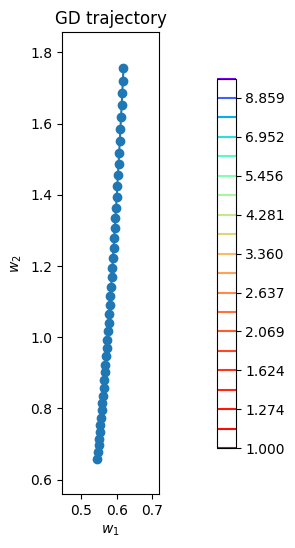

In [14]:
plot_gd(gradient_descent(w_init, X, y, loss, 0.0001, num_steps), X, y, loss)

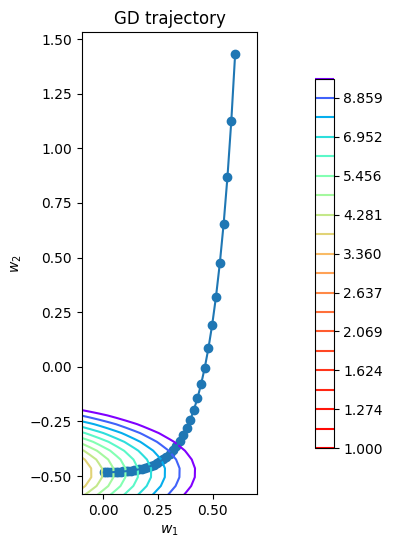

In [15]:
plot_gd(gradient_descent(w_init, X, y, loss, 0.001, num_steps), X, y, loss)

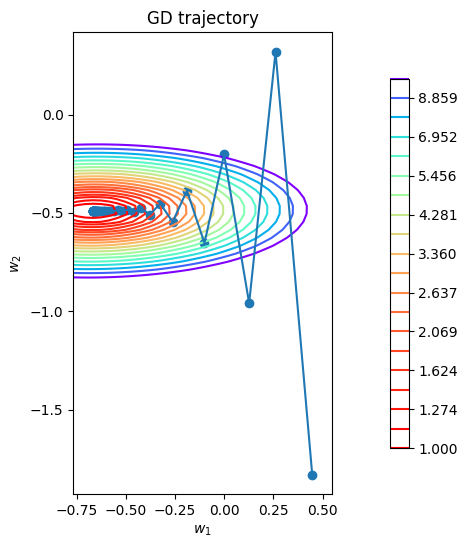

In [16]:
plot_gd(gradient_descent(w_init, X, y, loss, 0.01, num_steps), X, y, loss)

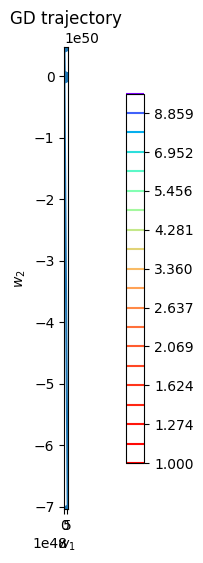

In [17]:
plot_gd(gradient_descent(w_init, X, y, loss, 0.1, num_steps), X, y, loss)

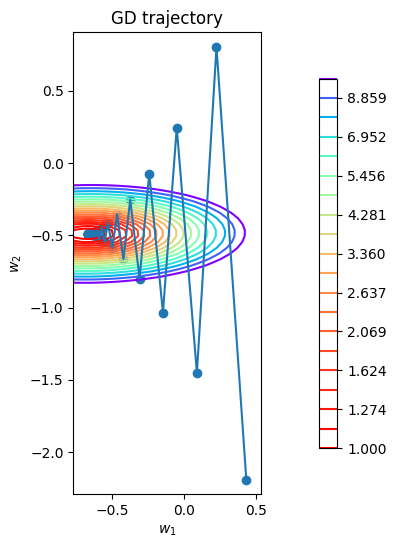

In [18]:
plot_gd(gradient_descent(w_init, X, y, loss, 0.011, num_steps), X, y, loss)

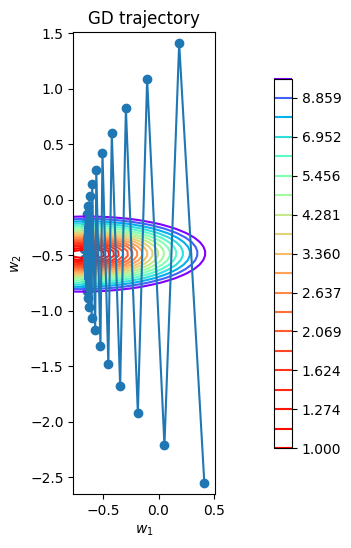

In [19]:
plot_gd(gradient_descent(w_init, X, y, loss, 0.012, num_steps), X, y, loss)

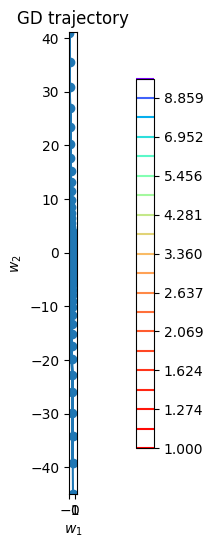

In [20]:
plot_gd(gradient_descent(w_init, X, y, loss, 0.013, num_steps), X, y, loss)

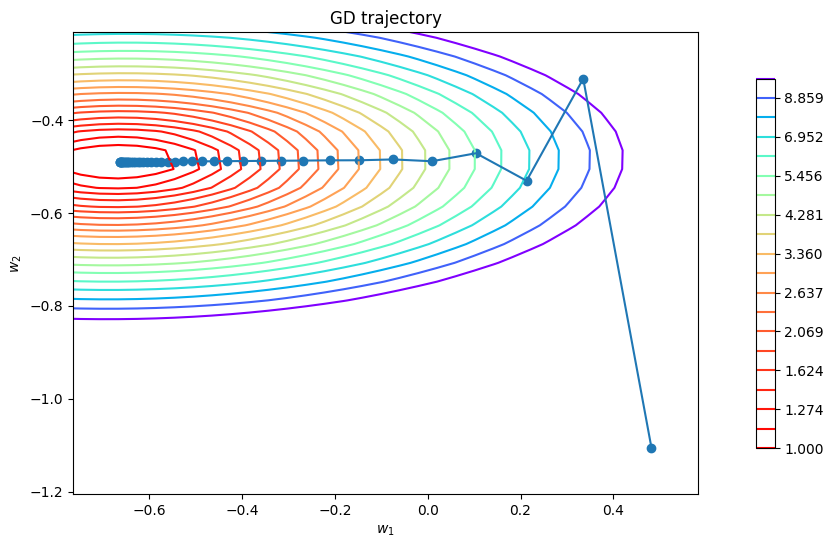

In [21]:
plot_gd(gradient_descent(w_init, X, y, loss, 0.008, num_steps), X, y, loss)

При слишком маленьком lr - (0,0001, 0,001). Наши шажки слишком маленькие и мы не доходим до цели

При lr = 0.01 - мы немного перепрыгивая доходим до цели

При lr = 0.1 - у нас слишком большие шаги и мы не можем сойтись

Из этого я сделал вывод, что нужно проверить 2 вещи:  
1) Когда мы начинаем люто перепрыгивать - и уже на 0.012 видны симптомы, а на 0.013 мы разошлись.
2) Где мы будем делать наименьшее количество телодвижений - при 0.008 мы с на третьем шаге встаём на нужное направление и идём прямо к минимуму

Теперь реализуем стохастический градиентный спуск.

**Задание 1.4 (5/8 балла):** Реализуйте функцию `stochastic_gradient_descent`.

Функция должна принимать все те же параметры, что и функция `gradient_descent`, но ещё параметр `batch_size`, отвечающий за размер батча.

Функция должна как и раньше реализовывать цикл, в котором происходит шаг градиентного спуска, но на каждом шаге считать градиент не по всей выборке `X`, а только по случайно выбранной части.

Подсказка: для выбора случайной части можно использовать [`np.random.choice`](https://numpy.org/doc/stable/reference/random/generated/numpy.random.choice.html) с правильным параметром `size`, чтобы выбрать случайные индексы, а потом проиндексировать получившимся массивом массив `X`:
```
batch_indices = np.random.choice(X.shape[0], size=batch_size, replace=False)
batch = X[batch_indices]
```

In [22]:
def stochastic_gradient_descent(
    w_init: np.ndarray,
    X: np.ndarray,
    y: np.ndarray,
    loss: BaseLoss,
    lr: float,
    batch_size: int,
    n_iterations: int = 1000,
) -> List[np.ndarray]:
    """
    Функция градиентного спуска
    :param w_init: np.ndarray размера (n_feratures,) -- начальное значение вектора весов
    :param X: np.ndarray размера (n_objects, n_features) -- матрица объекты-признаки
    :param y: np.ndarray размера (n_objects,) -- вектор правильных ответов
    :param loss: Объект подкласса BaseLoss, который умеет считать градиенты при помощи loss.calc_grad(X, y, w)
    :param lr: float -- параметр величины шага, на который нужно домножать градиент
    :param batch_size: int -- размер подвыборки, которую нужно семплировать на каждом шаге
    :param n_iterations: int -- сколько итераций делать
    :return: Список из n_iterations объектов np.ndarray размера (n_features,) -- история весов на каждом шаге
    """
    w = w_init.copy()
    way = []
    l = len(y)
    for i in range(n_iterations):
      batches = np.random.choice(l, batch_size, replace = batch_size > l)
      w = w - lr * loss.calc_grad(X[batches], y[batches], w)
      way.append(w.copy())
    return way

**Задание 1.5 (5/8 балла):** При помощи функций `stochastic_gradient_descent` и  `plot_gd` нарисуйте траекторию градиентного спуска для разных значений длины шага (параметра `lr`) и размера подвыборки (параметра `batch_size`). Используйте не менее четырёх разных значений для `lr` и `batch_size`.

Сделайте и опишите свои выводы о том, как параметры  `lr` и `batch_size` влияют на поведение стохастического градиентного спуска. Как отличается поведение стохастического градиентного спуска от обычного? Что происходит при малых и больших `batch_size`?

Обратите внимание, что в нашем датасете всего 300 объектов, так что `batch_size` больше этого числа не будет иметь смысла.

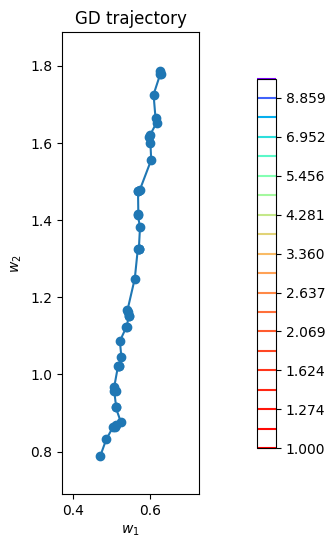

In [23]:
plot_gd(stochastic_gradient_descent(w_init, X, y, loss, 0.0001, 1, num_steps), X, y, loss)

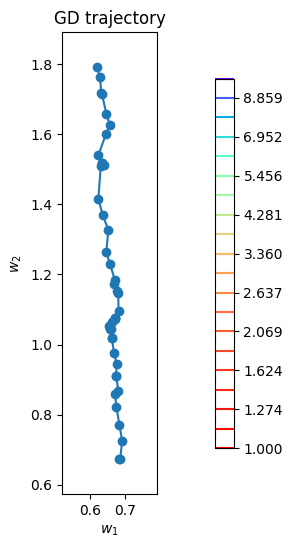

In [24]:
plot_gd(stochastic_gradient_descent(w_init, X, y, loss, 0.0001, 1, num_steps), X, y, loss)

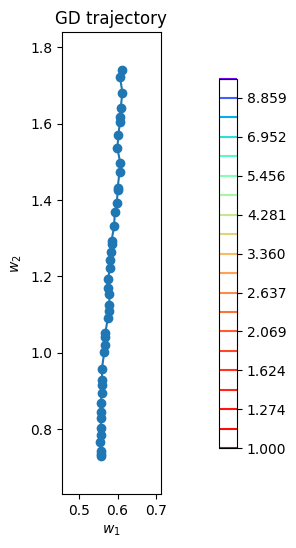

In [25]:
plot_gd(stochastic_gradient_descent(w_init, X, y, loss, 0.0001, 5, num_steps), X, y, loss)

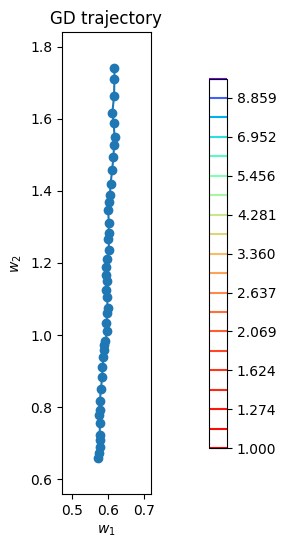

In [26]:
plot_gd(stochastic_gradient_descent(w_init, X, y, loss, 0.0001, 10, num_steps), X, y, loss)

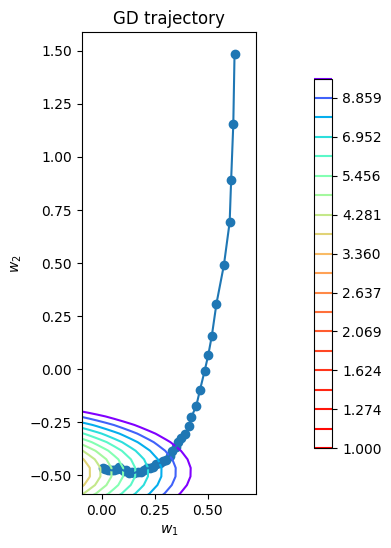

In [27]:
plot_gd(stochastic_gradient_descent(w_init, X, y, loss, 0.001, 50, num_steps), X, y, loss)

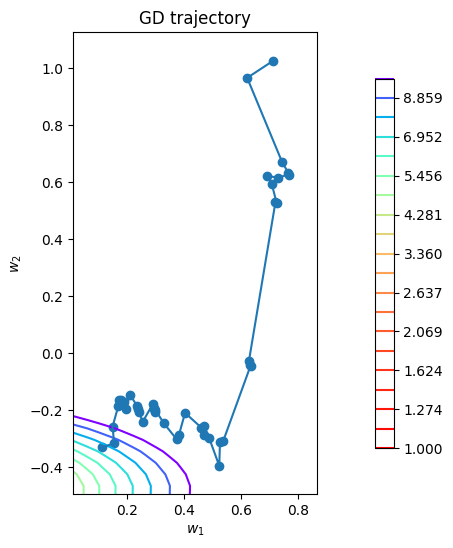

In [28]:
plot_gd(stochastic_gradient_descent(w_init, X, y, loss, 0.001, 1, num_steps), X, y, loss)

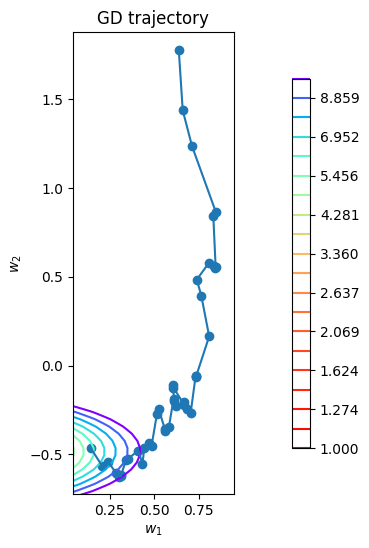

In [29]:
plot_gd(stochastic_gradient_descent(w_init, X, y, loss, 0.001, 1, num_steps), X, y, loss)

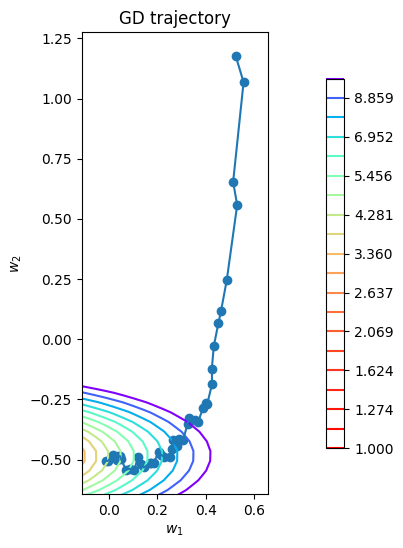

In [30]:
plot_gd(stochastic_gradient_descent(w_init, X, y, loss, 0.001, 5, num_steps), X, y, loss)

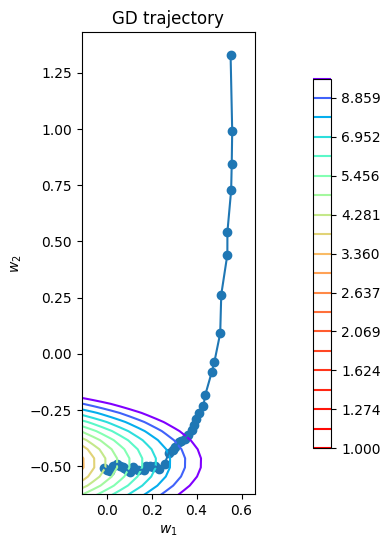

In [31]:
plot_gd(stochastic_gradient_descent(w_init, X, y, loss, 0.001, 10, num_steps), X, y, loss)

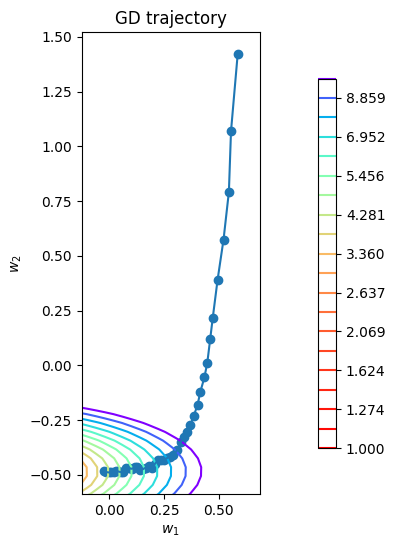

In [32]:
plot_gd(stochastic_gradient_descent(w_init, X, y, loss, 0.001, 50, num_steps), X, y, loss)

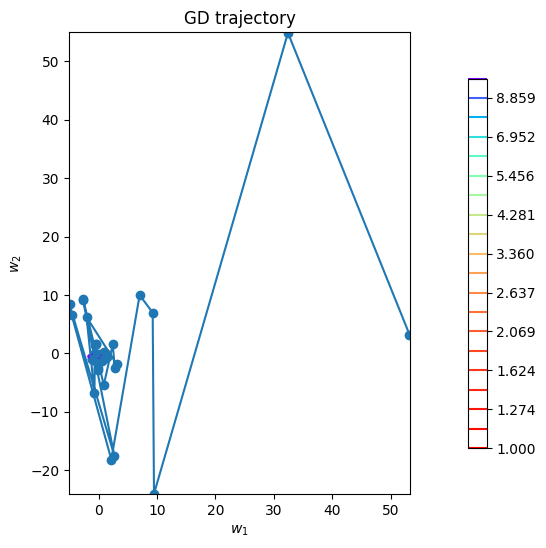

In [33]:
plot_gd(stochastic_gradient_descent(w_init, X, y, loss, 0.01, 1, num_steps), X, y, loss)

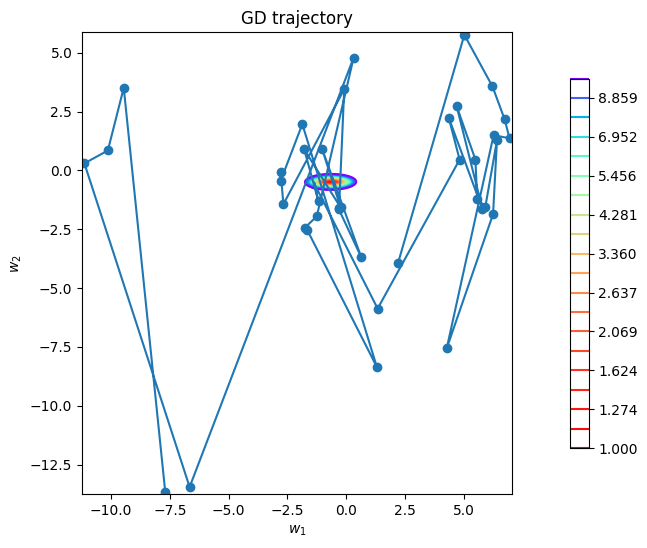

In [34]:
plot_gd(stochastic_gradient_descent(w_init, X, y, loss, 0.01, 1, num_steps), X, y, loss)

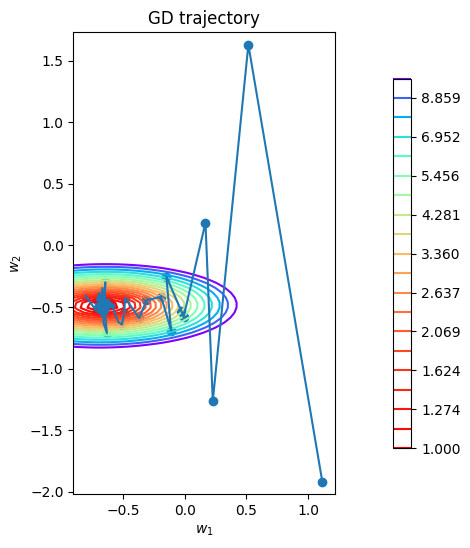

In [35]:
plot_gd(stochastic_gradient_descent(w_init, X, y, loss, 0.01, 5, num_steps), X, y, loss)

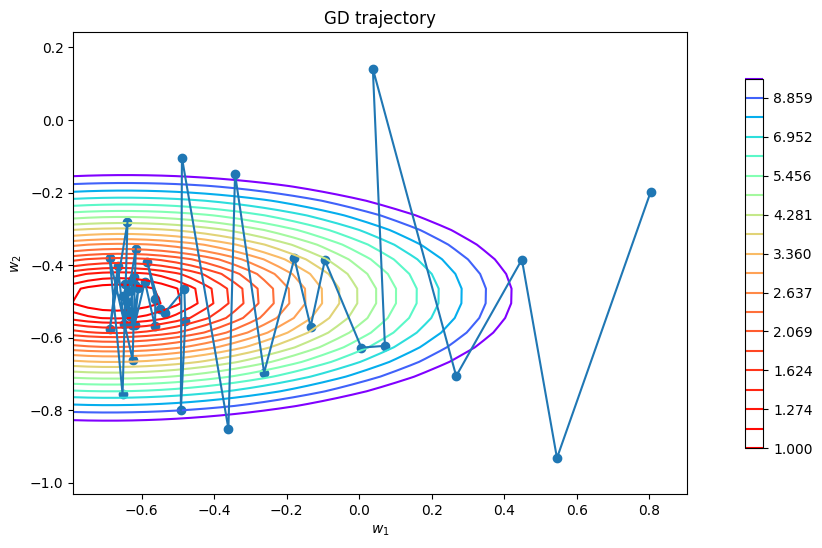

In [36]:
plot_gd(stochastic_gradient_descent(w_init, X, y, loss, 0.01, 10, num_steps), X, y, loss)

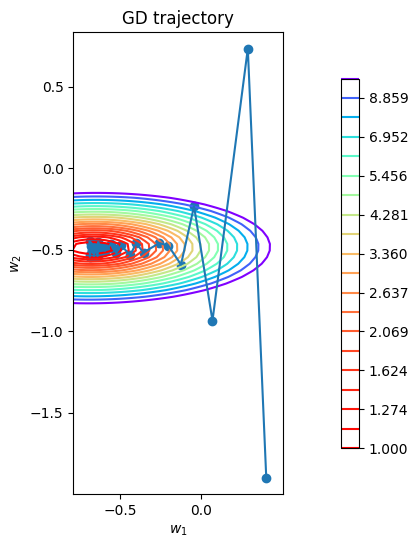

In [37]:
plot_gd(stochastic_gradient_descent(w_init, X, y, loss, 0.01, 50, num_steps), X, y, loss)

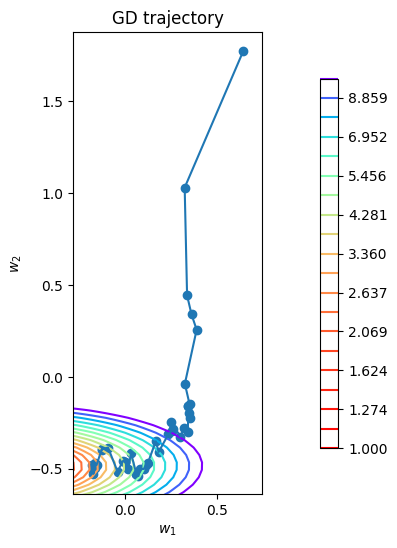

In [38]:
plot_gd(stochastic_gradient_descent(w_init, X, y, loss, 0.001, 1, num_steps), X, y, loss)

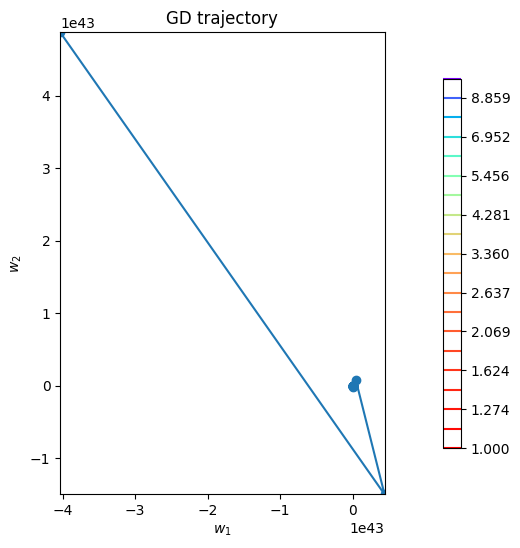

In [39]:
plot_gd(stochastic_gradient_descent(w_init, X, y, loss, 0.1, 1, num_steps), X, y, loss)

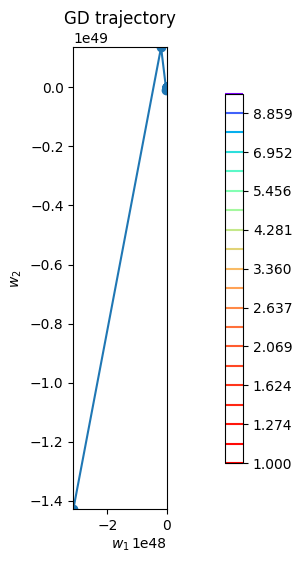

In [40]:
plot_gd(stochastic_gradient_descent(w_init, X, y, loss, 0.1, 5, num_steps), X, y, loss)

Из интересного - по lr ситуация такая же как и у обычного спуска. При первых двух не доходит до минимума, при последнем - расходится, а при 0.01 - всю хорошо.

Теперь про размер пакетов:
n=1 - мы полагаемся в основном на удачу, он ходит невероятно хаотично, но на удивление - оба раза при lr = 0.01 он закончил не очень далеко от минимума.

n=5, 10 - уже более менее стабильно и дошло до минимума

n = 50 - уже максимально хорошо, но мы и берём шестую часть выборки

Я бы предпочёл n = 10, так как это оптимальнпо и по ресурсам и по результату

Вы могли заметить, что поведение градиентного спуска, особенно стохастической версии, очень сильно зависит от размера шага.

Как правило, в начале спуска мы хотим делать большие шаги, чтобы поскорее подойти поближе к минимуму, а позже мы уже хотим делать шаги маленькие, чтобы точнее этого минимума достигнуть и не "перепрыгнуть" его.

Чтобы достичь такого поведения мы можем постепенно уменьшать длину шага с увеличением номера итерации. Сделать это можно, например, вычисляя на каждой итерации длину шага по следующей формуле:

$$
    \eta_t
    =
    \lambda
    \left(
        \frac{s_0}{s_0 + t}
    \right)^p
$$

где $\eta_t$ — длина шага на итерации $t$, $\lambda$ — начальная длина шага (параметр `lr` у нас), $s_0$ и $p$ — настраиваемые параметры.

**Задание 1.6 (5/8 балла):** Реализуйте функцию `stochastic_gradient_descent` на этот раз с затухающим шагом по формуле выше. Параметр $s_0$ возьмите равным 1. Параметр $p$ возьмите из нового аргумента функции `p`.

In [41]:
def stochastic_gradient_descent(
    w_init: np.ndarray,
    X: np.ndarray,
    y: np.ndarray,
    loss: BaseLoss,
    lr: float,
    batch_size: int,
    p: float,
    n_iterations: int = 1000,
) -> List[np.ndarray]:
    """
    Функция градиентного спуска
    :param w_init: np.ndarray размера (n_feratures,) - начальное значение вектора весов
    :param X: np.ndarray размера (n_objects, n_features) - матрица объекты-признаки
    :param y: np.ndarray размера (n_objects,) - вектор правильных ответов
    :param loss: Объект подкласса BaseLoss, который умеет считать градиенты при помощи loss.calc_grad(X, y, w)
    :param lr: float - параметр величины шага, на который нужно домножать градиент
    :param batch_size: int - размер подвыборки, которую нужно семплировать на каждом шаге
    :param p: float - значение степени в формуле затухания длины шага
    :param n_iterations: int - сколько итераций делать
    :return: Список из n_iterations объектов np.ndarray размера (n_features,) - история весов на каждом шаге
    """
    w = w_init.copy()
    way = []
    l = len(y)
    for i in range(n_iterations):
      lyam = lr / (1+i)**p
      batches = np.random.choice(l, batch_size, replace = batch_size > l)
      w = w - lyam * loss.calc_grad(X[batches], y[batches], w)
      way.append(w.copy())
    return way

**Задание 1.7 (5/8 балла):** При помощи новой функции `stochastic_gradient_descent` и функции `plot_gd` нарисуйте траекторию градиентного спуска для разных значений параметра `p`. Используйте не менее четырёх разных значений для `p`. Хорошими могут быть значения, лежащие в промежутке от 0.1 до 1.
Параметр `lr` возьмите равным 0.01, а параметр `batch_size` равным 10.

Сделайте и опишите свои выводы о том, как параметр `p` влияет на поведение стохастического градиентного спуска. Что происходит при маленьком или большом значении p?

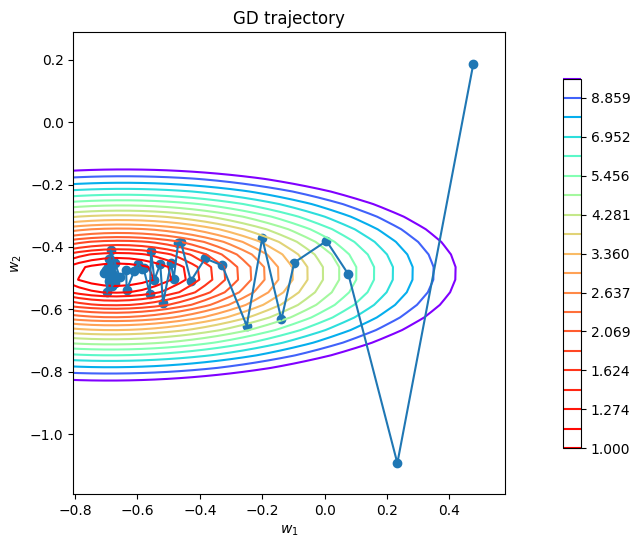

In [42]:
plot_gd(stochastic_gradient_descent(w_init, X, y, loss, 0.01, 10, 0.1, num_steps), X, y, loss)

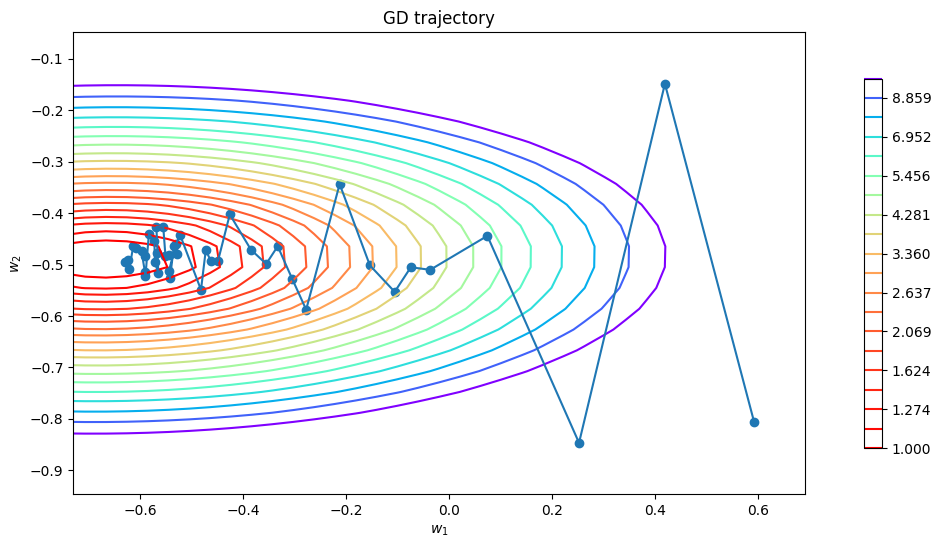

In [43]:
plot_gd(stochastic_gradient_descent(w_init, X, y, loss, 0.01, 10, 0.2, num_steps), X, y, loss)

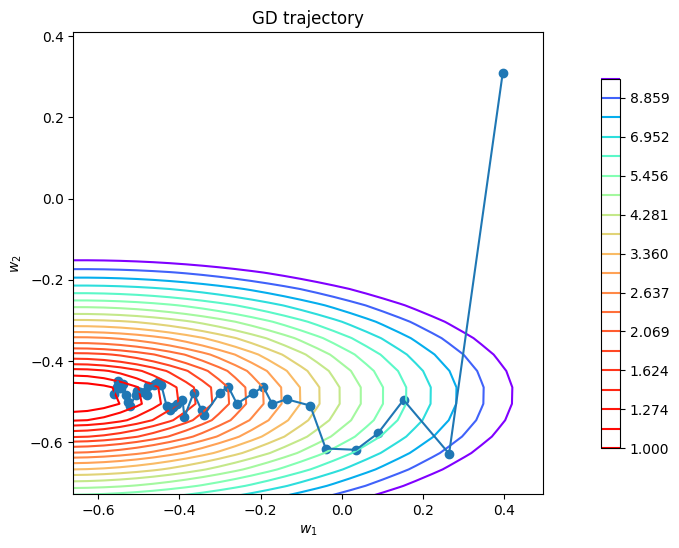

In [44]:
plot_gd(stochastic_gradient_descent(w_init, X, y, loss, 0.01, 10, 0.4, num_steps), X, y, loss)

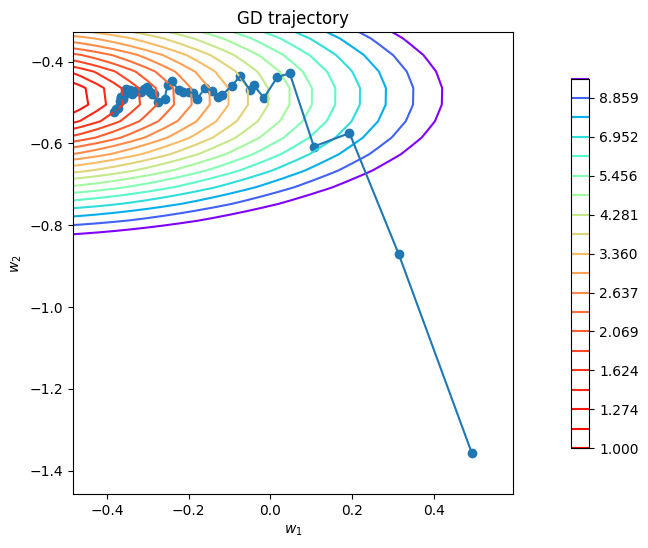

In [45]:
plot_gd(stochastic_gradient_descent(w_init, X, y, loss, 0.01, 10, 0.6, num_steps), X, y, loss) #впервые вижу,чтобы оно с другой стороны пошло :)

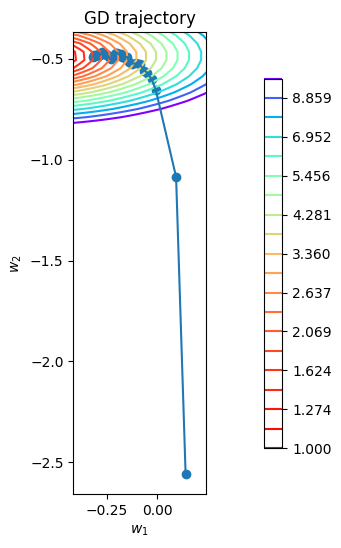

In [46]:
plot_gd(stochastic_gradient_descent(w_init, X, y, loss, 0.01, 10, 0.8, num_steps), X, y, loss)

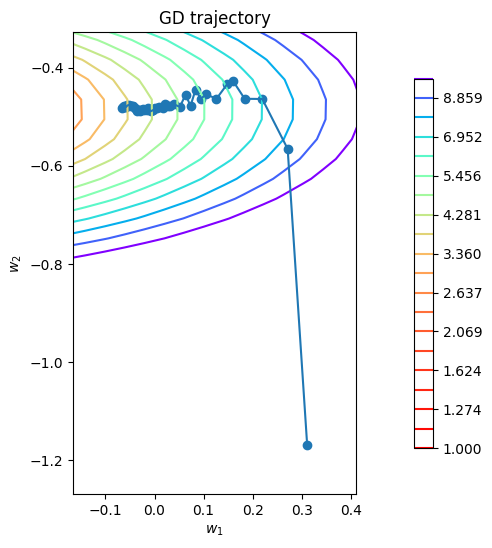

In [47]:
plot_gd(stochastic_gradient_descent(w_init, X, y, loss, 0.01, 10, 1, num_steps), X, y, loss)

Лучше всего себя показали значения p =0.01 и p = 0.02
Все остальные слишком быстро затыхают и не дроходят до минимума. А при маленьких - он дстаточно хорошо идёт

**Задание 1.8 (5/8 балла):** Сравните сходимость обычного градиентного спуска и стохастичекой версии:
Нарисуйте график зависимости значения лосса (его можно посчитать при помощи метода `calc_loss`, используя $x$ и $y$ из датасета и $w$ с соответствующей итерации) от номера итерации для траекторий, полученных при помощи обычного и стохастического градиентного спуска с одинаковыми параметрами. Параметр `batch_size` возьмите равным 10.

Видно ли на данном графике преимущество SGD? Почему?

In [48]:
def stochastic_gradient_descent(
    w_init: np.ndarray,
    X: np.ndarray,
    y: np.ndarray,
    loss: BaseLoss,
    lr: float,
    batch_size: int,
    n_iterations: int = 1000,
) -> List[np.ndarray]:
    """
    Функция градиентного спуска
    :param w_init: np.ndarray размера (n_feratures,) -- начальное значение вектора весов
    :param X: np.ndarray размера (n_objects, n_features) -- матрица объекты-признаки
    :param y: np.ndarray размера (n_objects,) -- вектор правильных ответов
    :param loss: Объект подкласса BaseLoss, который умеет считать градиенты при помощи loss.calc_grad(X, y, w)
    :param lr: float -- параметр величины шага, на который нужно домножать градиент
    :param batch_size: int -- размер подвыборки, которую нужно семплировать на каждом шаге
    :param n_iterations: int -- сколько итераций делать
    :return: Список из n_iterations объектов np.ndarray размера (n_features,) -- история весов на каждом шаге
    """
    w = w_init.copy()
    way = []
    l = len(y)
    for i in range(n_iterations):
      batches = np.random.choice(l, batch_size, replace = batch_size > l)
      w = w - lr * loss.calc_grad(X[batches], y[batches], w)
      way.append(w.copy())
    return way

In [55]:
gd_losses = [loss.calc_loss(X, y, w) for w in gradient_descent(w_init, X, y, loss, 0.008, 100)]
sgd_losses = [loss.calc_loss(X, y, w) for w in stochastic_gradient_descent(w_init, X, y, loss, 0.008, 10, 100)]

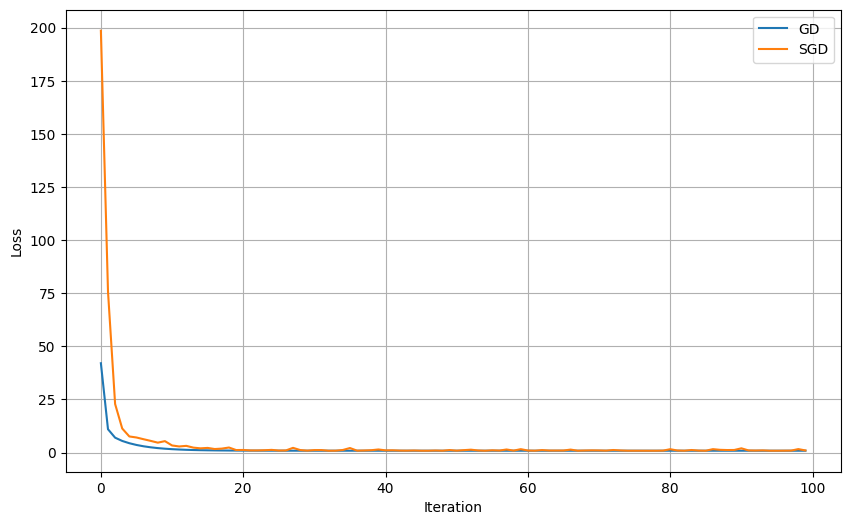

In [148]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.plot(gd_losses, label="GD")
plt.plot(sgd_losses, label="SGD")

plt.xlabel("Iteration")
plt.ylabel("Loss")

plt.legend()
plt.grid()

plt.show()

Они идут очень близко. Только может стохастический в начале похуже. Но при этом стожастический работает в 30 раз быстрее. Поэтому он лучше

## Часть 2. Линейная регрессия (5 баллов)

Теперь давайте напишем наш класс для линейной регрессии. Он будет использовать интерфейс, знакомый нам из библиотеки `sklearn`.

В методе `fit` мы будем подбирать веса `w` при помощи градиентного спуска нашим методом `gradient_descent`.

В методе `predict` мы будем применять нашу регрессию к датасету.

**Задание 2.1 (5/8 балла):** Допишите код в методах `fit` и `predict` класса `LinearRegression`.

В методе `fit` вам нужно как-то инициализировать веса `w`, применить `gradient_descent` и сохранить последнюю `w` из траектории.

В методе `predict` вам нужно применить линейную регрессию и вернуть вектор ответов.

Обратите внимание, что объект лосса передаётся в момент инициализации и хранится в `self.loss`. Его нужно использовать в `fit` для `gradient_descent`.

In [72]:
class LinearRegression:
    def __init__(self, loss: BaseLoss, lr: float = 0.1) -> None:
        self.loss = loss
        self.lr = lr

    def fit(self, X: np.ndarray, y: np.ndarray) -> "LinearRegression":
        X = np.asarray(X)
        y = np.asarray(y)
        # Добавляем столбец из единиц для константного признака
        X = np.hstack([X, np.ones([X.shape[0], 1])])

        w_init = np.zeros(X.shape[1])

        self.w = gradient_descent(w_init, X, y, self.loss, self.lr)[-1]

        return self

    def predict(self, X: np.ndarray) -> np.ndarray:
        # Проверяем, что регрессия обучена, то есть, что был вызван fit и в нём был установлен атрибут self.w
        assert hasattr(self, "w"), "Linear regression must be fitted first"
        # Добавляем столбец из единиц для константного признака
        X = np.hstack([X, np.ones([X.shape[0], 1])])

        return X @ self.w

Теперь у нас есть наш класс линейной регрессии. Более того, мы можем управлять тем, какую функцию потерь мы оптимизируем, просто передавая разные классы в параметр `loss` при инициализации.

Пока у нас нет никаких классов кроме `MSELoss`, но скоро они появятся.

Для `MSELoss` мы бы создавали наш объект линейной регрессии, например, так:

In [52]:
linear_regression = LinearRegression(MSELoss())

Применим нашу регрессию на реальном датасете. Загрузим датасет с машинами, который был у вас на семинарах:

In [84]:
import pandas as pd

X_raw = pd.read_csv(
    "cars_data.csv",
    header=None,
    na_values=["?"],
    skiprows=1,
    index_col=0
)
X_raw = X_raw[~X_raw[26].isna()].reset_index(drop=True)
X_raw.head()

,1,2,3,4,5,6,7,8,9,10,...,17,18,19,20,21,22,23,24,25,26
0,3,NaN,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,13495.0
1,3,NaN,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,16500.0
2,1,NaN,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154.0,5000.0,19,26,16500.0
3,2,164.0,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102.0,5500.0,24,30,13950.0
4,2,164.0,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115.0,5500.0,18,22,17450.0


In [85]:
y = X_raw[26]
X_raw = X_raw.drop(26, axis=1)

**Задание 2.2 (5/8 балла):** Как обычно обработайте датасет всеми нужными методами, чтобы на нём можно было обучать линейную регрессию:

* Разделите датасет на обучающую и тестовую выборку
* Заполните пропуски
* Нормализуйте числовые признаки
* Закодируйте категориальные переменные

In [86]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_raw, y, test_size=0.3, random_state=228
)

In [87]:
X_train[X_train.select_dtypes(include=["int64", "float64"]).columns] = X_train.select_dtypes(include=["int64", "float64"]).fillna(X_train.select_dtypes(include=["int64", "float64"]).median())
X_test[X_test.select_dtypes(include=["int64", "float64"]).columns] = X_test.select_dtypes(include=["int64", "float64"]).fillna(X_train.select_dtypes(include=["int64", "float64"]).median())
X_train[X_train.select_dtypes(include=["object"]).columns] = X_train.select_dtypes(include=["object"]).fillna(X_train.select_dtypes(include=["object"]).mode().iloc[0])
X_test[X_test.select_dtypes(include=["object"]).columns] = X_test.select_dtypes(include=["object"]).fillna(X_train.select_dtypes(include=["object"]).mode().iloc[0])

In [88]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train[X_train.select_dtypes(include=["int64", "float64"]).columns] = scaler.fit_transform(X_train.select_dtypes(include=["int64", "float64"]))
X_test[X_test.select_dtypes(include=["int64", "float64"]).columns] = scaler.transform(X_test.select_dtypes(include=["int64", "float64"]))

In [89]:
for cols in X_train.select_dtypes(include=["object"]).columns:
  print(X_train[cols].unique())

['volvo' 'alfa-romero' 'mazda' 'renault' 'mercedes-benz' 'porsche'
 'mitsubishi' 'peugot' 'toyota' 'honda' 'plymouth' 'nissan' 'subaru'
 'volkswagen' 'jaguar' 'bmw' 'dodge' 'audi' 'chevrolet' 'saab' 'isuzu']
['gas' 'diesel']
['std' 'turbo']
['four' 'two']
['sedan' 'convertible' 'hatchback' 'hardtop' 'wagon']
['rwd' 'fwd' '4wd']
['front' 'rear']
['ohc' 'dohc' 'ohcv' 'ohcf' 'l' 'rotor']
['four' 'eight' 'six' 'five' 'two' 'three']
['mpfi' '2bbl' 'spdi' '1bbl' 'idi' '4bbl' 'mfi']


Ну вроде бы приемлемое количество классов для dummies. И ни каких подвохов я не считал

In [109]:
X_train = pd.get_dummies(X_train, columns= X_train.select_dtypes(include=["object"]).columns)
X_test = pd.get_dummies(X_test, columns= X_test.select_dtypes(include=["object"]).columns)

X_train, X_test = X_train.align(X_test, join="left", axis=1, fill_value=0)

In [110]:
X_train

,1,2,10,11,12,13,14,17,19,20,...,16_six,16_three,16_two,18_1bbl,18_2bbl,18_4bbl,18_idi,18_mfi,18_mpfi,18_spdi
190,-2.179860,-0.400973,0.971086,1.292204,0.794760,1.008474,0.814205,0.467195,1.649065,-0.368981,...,False,False,False,False,False,False,False,False,True,False
0,1.683183,-0.307361,-1.639219,-0.359703,-0.756863,-2.068024,0.093384,0.179403,0.523583,-1.910502,...,False,False,False,False,False,False,False,False,True,False
49,0.137966,-0.369769,-0.891043,-1.160877,-0.706811,0.135413,-1.179934,-0.840951,-1.073876,-0.368981,...,False,False,False,False,True,False,False,False,False,False
127,0.910574,-0.307361,-0.392258,0.301060,0.494446,-1.361261,-0.080880,0.231729,0.487277,2.090893,...,False,False,False,False,False,False,False,False,True,False
68,-1.407251,-0.307361,2.849840,2.432019,3.047115,1.133196,2.453875,2.900348,0.487277,-0.532973,...,False,False,False,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24,0.137966,1.003213,-0.791286,-1.309549,-0.907020,-1.319687,-1.013591,-0.867114,-1.291711,-0.106595,...,False,False,False,False,True,False,False,False,False,False
44,-0.634643,0.909600,2.417560,2.184233,1.996016,-0.405052,3.099445,3.528258,1.104477,2.976447,...,True,False,False,False,False,False,False,False,True,False
115,0.137966,0.098293,-0.791286,-1.309549,-0.907020,-1.236538,-1.154190,-0.867114,-1.291711,-0.106595,...,False,False,False,False,True,False,False,False,False,False
144,-0.634643,-0.962647,-0.259249,0.036755,-0.106182,0.468008,-0.160091,-0.396182,1.068171,-2.041695,...,False,False,False,False,True,False,False,False,False,False


In [111]:
X_test

,1,2,10,11,12,13,14,17,19,20,...,16_six,16_three,16_two,18_1bbl,18_2bbl,18_4bbl,18_idi,18_mfi,18_mpfi,18_spdi
99,-0.634643,-0.244952,0.322666,0.945303,0.444393,0.966899,1.574632,1.513713,0.378359,0.024599,...,True,0,False,False,False,False,False,0,True,False
132,1.683183,1.065621,0.106526,1.110494,0.444393,0.966899,0.608256,-0.056063,0.777724,-0.631368,...,False,0,False,False,False,False,False,0,True,False
15,-0.634643,-0.307361,0.838076,1.705180,1.145126,-0.030884,1.740975,2.246275,1.068171,0.418179,...,True,0,False,False,False,False,False,0,True,False
101,1.683183,2.438602,-1.190313,-0.202771,1.145126,-1.693856,1.129069,1.513713,0.378359,0.024599,...,True,0,False,False,False,False,False,0,True,False
52,1.683183,1.065621,-0.525267,-0.343184,0.043975,-1.735430,-0.239302,-1.390373,-0.202535,0.090195,...,False,0,True,False,False,True,False,0,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
57,-0.634643,-0.026524,0.056648,0.383655,0.444393,0.717454,-0.179894,-0.029900,0.233136,0.418179,...,False,0,False,False,True,False,False,0,False,False
159,0.137966,1.627295,-0.658277,-0.367962,-0.806915,-0.488201,-0.657141,-0.657811,-0.492982,-0.762561,...,False,0,False,False,True,False,False,0,False,False
43,0.910574,-0.307361,-0.408884,-0.045840,-0.206287,-0.987093,0.461716,-0.108389,0.378359,-0.106595,...,False,0,False,False,False,False,False,0,False,False
33,0.137966,-0.463381,-0.791286,-1.912494,-0.806915,-0.488201,-1.078940,-0.814788,-1.509547,0.483775,...,False,0,False,True,False,False,False,0,False,False


**Задание 2.3 (5/8 балла):** Обучите написанную вами линейную регрессию на обучающей выборке

In [112]:
X_train = X_train.to_numpy(dtype=float)
X_test = X_test.to_numpy(dtype=float)

y_train = y_train.to_numpy(dtype=float)
y_test = y_test.to_numpy(dtype=float)

linear_regression.fit(X_train, y_train)

In [113]:
y_train_pred = linear_regression.predict(X_train)
y_test_pred = linear_regression.predict(X_test)

**Задание 2.4 (5/8 балла):** Посчитайте ошибку обученной регрессии на обучающей и тестовой выборке при помощи метода `mean_squared_error` из `sklearn.metrics`.

In [115]:
from sklearn.metrics import mean_squared_error

print("Train: ", mean_squared_error(y_train, y_train_pred))
print("Test: ", mean_squared_error(y_test, y_test_pred))

Train:  1247128.636516835
Test:  18742851.771547534


Наша модель переобучилась. Давайте как обычно в такой ситуации добавим к ней L2 регуляризацию. Для этого нам нужно написать новый класс лосса.

Формула функции потерь для MSE с L2 регуляризацией выглядит так:
$$
Q(w, X, y) = \frac{1}{\ell} \sum\limits_{i=1}^\ell (\langle x_i, w \rangle - y_i)^2 + \lambda ||w||^2
$$

Или в матричном виде:

$$
Q(w, X, y) = \frac{1}{\ell} || Xw - y ||^2 + \lambda ||w||^2
$$

Где $\lambda$ — коэффициент регуляризации.

Градиент выглядит так:

$$
\nabla_w Q(w, X, y) = \frac{2}{\ell} X^T(Xw-y) + 2 \lambda w
$$

**Задание 2.5 (5/8 балла):** Реализуйте класс `MSEL2Loss`.

Он должен вычислять лосс и градиент по формулам выше.

Подсказка: обратите внимание, что последний элемент вектора `w` — это bias (в классе `LinearRegression` к матрице `X` добавляется колонка из единиц — константный признак). Как мы знаем из лекций и семинаров, bias регуляризовать не нужно. Поэтому не забудьте убрать последний элемент из `w` при подсчёте слагаемого $\lambda||w||^2$ в `calc_loss` и занулить его при подсчёте слагаемого $2 \lambda w$ в `calc_grad`.

In [116]:
class MSEL2Loss(BaseLoss):
    def __init__(self, coef: float = 1.0):
        """
        :param coef: коэффициент регуляризации (лямбда в формуле)
        """
        self.coef = coef

    def calc_loss(self, X: np.ndarray, y: np.ndarray, w: np.ndarray) -> float:
        """
        Функция для вычислений значения лосса
        :param X: np.ndarray размера (n_objects, n_features) с объектами датасета. Последний признак константный.
        :param y: np.ndarray размера (n_objects,) с правильными ответами
        :param w: np.ndarray размера (n_features,) с весами линейной регрессии. Последний вес -- bias.
        :output: число -- значения функции потерь
        """
        l = len(y)
        return np.linalg.norm(X@ w - y)**2/l + self.coef * np.linalg.norm(w[:-1])**2

    def calc_grad(self, X: np.ndarray, y: np.ndarray, w: np.ndarray) -> np.ndarray:
        """
        Функция для вычислений градиента лосса по весам w
        :param X: np.ndarray размера (n_objects, n_features) с объектами датасета
        :param y: np.ndarray размера (n_objects,) с правильными ответами
        :param w: np.ndarray размера (n_features,) с весами линейной регрессии
        :output: np.ndarray размера (n_features,) градиент функции потерь по весам w
        """
        l = len(y)
        res = 2* X.T @ (X@ w - y) / l
        res[:-1] += 2 * self.coef * w[:-1]
        return res

Теперь мы можем использовать лосс с l2 регуляризацией в нашей регрессии, например, так:

In [123]:
linear_regression = LinearRegression(MSEL2Loss(0.1))

**Задание 2.6 (5/8 балла):** Обучите регрессию с лоссом `MSEL2Loss`. Подберите хороший коэффициент регуляризации и добейтесь улучшения результата на тестовой выборке. Сравните результат на обучающей и тестовой выборке с регрессией без регуляризации.

In [124]:
linear_regression.fit(X_train, y_train)

y_train_pred = linear_regression.predict(X_train)
y_test_pred = linear_regression.predict(X_test)

In [125]:
from sklearn.metrics import mean_squared_error

print("Train: ", mean_squared_error(y_train, y_train_pred))
print("Test: ", mean_squared_error(y_test, y_test_pred))

Train:  4299236.373549247
Test:  13238705.852882147


In [128]:
for i in [0.0001, 0.0005, 0.001, 0.005, 0.01, 0.05, 0.1, 0.5, 1]:
  print(f"--------------{i}--------------")
  linear_regression = LinearRegression(MSEL2Loss(i))
  linear_regression.fit(X_train, y_train)

  y_train_pred = linear_regression.predict(X_train)
  y_test_pred = linear_regression.predict(X_test)

  print("Train: ", mean_squared_error(y_train, y_train_pred))
  print("Test: ", mean_squared_error(y_test, y_test_pred))

--------------0.0001--------------
Train:  1253930.0129073355
Test:  16590085.601748813
--------------0.0005--------------
Train:  1306079.1742850768
Test:  13420235.502293425
--------------0.001--------------
Train:  1357940.267996954
Test:  12486165.841855962
--------------0.005--------------
Train:  1643136.2801902217
Test:  12701233.757620588
--------------0.01--------------
Train:  1942562.2789086606
Test:  13300682.499366611
--------------0.05--------------
Train:  3344359.0678463117
Test:  13636330.83546975
--------------0.1--------------
Train:  4299236.373549247
Test:  13238705.852882147
--------------0.5--------------
Train:  8097561.070124879
Test:  13583072.03649159
--------------1--------------
Train:  10703418.03010874
Test:  15328092.060905369


Лучше всего подошел lr = 0.001 он позволил на треть примерно уменьшить ошибку на тесте

В нашем датасете могут быть выбросы. На семинаре вам рассказывали, что с выбросами хорошо помогает бороться Huber Loss. Вдали от нуля он работает как Mean Absolute Error и не реагирует на выбросы так сильно, как MSE. Давайте его реализуем и применим в нашей регрессии.

Напомним, что функция потерь Huber Loss'а  выглядит так:


$$
    Q(w, X, y) = \frac{1}{\ell} \sum\limits_{i=1}^\ell \phi_\varepsilon (\langle x_i, w \rangle - y_i)
$$
$$
    \phi_\varepsilon(z) = \begin{cases} \frac 1 2 z^2, - \varepsilon < z < \varepsilon, \\\varepsilon (|z| - \frac 1 2 \varepsilon), иначе \\ \end{cases}
$$


А градиент так:
$$
    \nabla_w Q(w, X, y) = \frac{1}{\ell} \sum\limits_{i=1}^\ell x_i \nabla_z \phi_\varepsilon (\langle x_i, w \rangle - y_i)
$$
$$
    \nabla_z \phi_\varepsilon(z) = \begin{cases} z, - \varepsilon < z < \varepsilon, \\\varepsilon \text{ sign}(z), иначе \\ \end{cases}
$$

**Задание 2.7 (5/8 балла):** Реализуйте класс `HuberLoss`.

Он должен вычислять лосс и градиент по формулам выше.

In [129]:
class HuberLoss(BaseLoss):
    def __init__(self, eps: float) -> None:
        """
        :param eps: параметр huber loss из формулы
        """
        self.eps = eps

    def calc_loss(self, X: np.ndarray, y: np.ndarray, w: np.ndarray) -> float:
        """
        Функция для вычислений значения лосса
        :param X: np.ndarray размера (n_objects, n_features) с объектами датасета
        :param y: np.ndarray размера (n_objects,) с правильными ответами
        :param w: np.ndarray размера (n_features,) с весами линейной регрессии
        :output: число -- значения функции потерь
        """
        l = len(y)
        z = X @ w - y

        return np.mean(np.where(abs(z) <= self.eps, 0.5 * z**2, self.eps * (abs(z) - 0.5 * self.eps)
    ))

    def calc_grad(self, X: np.ndarray, y: np.ndarray, w: np.ndarray) -> np.ndarray:
        """
        Функция для вычислений градиента лосса по весам w
        :param X: np.ndarray размера (n_objects, n_features) с объектами датасета
        :param y: np.ndarray размера (n_objects,) с правильными ответами
        :param w: np.ndarray размера (n_features,) с весами линейной регрессии
        :output: np.ndarray размера (n_features,) градиент функции потерь по весам w
        """
        l = len(y)
        z = X @ w - y


        return X.T @ np.where(np.abs(z) <= self.eps, z, self.eps * np.sign(z)) / l

**Задание 2.8 (5/8 балла):** Обучите регрессию с лоссом `HuberLoss`. Сравните результат на обучающей и тестовой выборке с регрессией, обученной c `MSELoss`.

In [140]:
linear_regression = LinearRegression(HuberLoss(100))

linear_regression.fit(X_train, y_train)

y_train_pred = linear_regression.predict(X_train)
y_test_pred = linear_regression.predict(X_test)

print("Train: ", mean_squared_error(y_train, y_train_pred))
print("Test: ", mean_squared_error(y_test, y_test_pred))

Train:  1619051.7540544688
Test:  11194373.895479085


Хубер самый крутой

**Задание 3 (0.08/8 балла)**
Вставьте ваш любимый мем 2025 в ячейку ниже:

In [ ]:
https://youtu.be/2Wl3Jxtx0ls?si=782ABQhSbgHCSFbd

### БОНУС (2 балла)

Градиентный спуск — далеко не единственный метод оптимизации.
Другой очень известный метод называется ["Алгоритм имитации отжига"](https://ru.wikipedia.org/wiki/%D0%90%D0%BB%D0%B3%D0%BE%D1%80%D0%B8%D1%82%D0%BC_%D0%B8%D0%BC%D0%B8%D1%82%D0%B0%D1%86%D0%B8%D0%B8_%D0%BE%D1%82%D0%B6%D0%B8%D0%B3%D0%B0). Он не так часто используется для оптимизации моделей машинного обучения, но у вас есть уникальная возможность попробовать применить его к нашей любимой линейной регрессии.

**Задание (2 балла)**:
Напишите алгоритм имитации отжига для оптимизации MSE линейной регрессии.

Сравните результат с градиентным спуском по "траектории" и по финальному лоссу.

Подсказка: каждую новую точку (веса регресси в нашем случае) можно семплировать из некоторого случайного распределения с центром в текущей точке. Хорошо подойдут распределения с "тяжёлыми" хвостами, например, распределение Стьюдента с параметром количества степеней свободы в районе 3.
Это может выглядеть, например, так:
```
new_w = old_w + np.random.standard_t(3, size=old_w.shape)
```
С параметром распределения можно поэксперементировать: чем он больше, тем реже новые точки будут очень сильно уходить от старых.

In [145]:
def otzig( w_init: np.ndarray, X: np.ndarray, y: np.ndarray, n_iterations: int = 100000, T0: float = 1.0, alpha: float = 0.999):
  w = w_init.copy()
  way = []

  current_loss = np.mean((X @ w - y) ** 2)
  T = T0

  for i in range(n_iterations):
        new_w = w + np.random.standard_t(3, size=w.shape)

        proposal_loss = np.mean((X @ new_w - y) ** 2)

        if proposal_loss < current_loss:
            w = new_w
            current_loss = proposal_loss
        else:
            p = np.exp(-(proposal_loss - current_loss) / T)
            if np.random.rand() < p:
              w = new_w
              current_loss = proposal_loss

        way.append(w.copy())

        T *= alpha

  return way

(300, 2)
(300,)


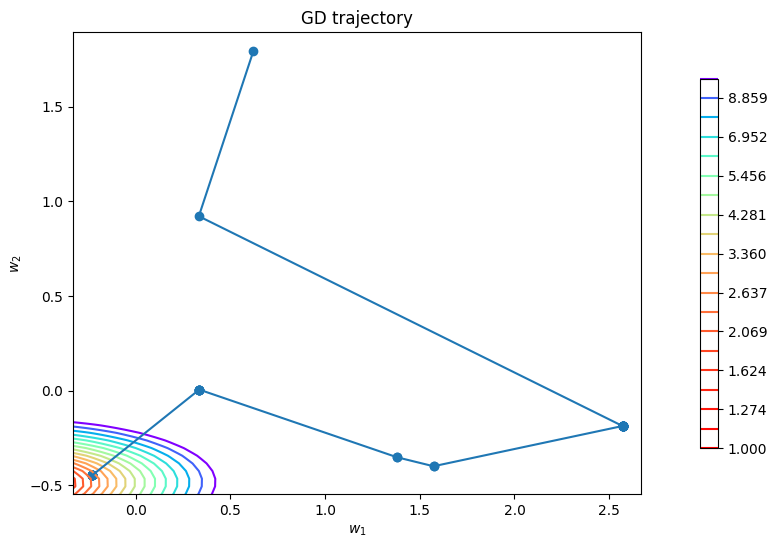

In [154]:
np.random.seed(1337)

n_features = 2
n_objects = 300
batch_size = 10
num_steps = 43

w_true = np.random.normal(size=(n_features,))

X = np.random.uniform(-5, 5, (n_objects, n_features))
X *= (np.arange(n_features) * 2 + 1)[np.newaxis, :] # разные масштабы признаков
y = X.dot(w_true) + np.random.normal(0, 1, (n_objects))
w_init = np.random.uniform(-2, 2, (n_features))

print(X.shape)
print(y.shape)

plot_gd(otzig(w_init, X, y, num_steps), X, y, loss)

In [155]:
gd_losses = [loss.calc_loss(X, y, w) for w in gradient_descent(w_init, X, y, loss, 0.008, 100)]
otzig_losses = [loss.calc_loss(X, y, w) for w in otzig(w_init, X, y, 100)]

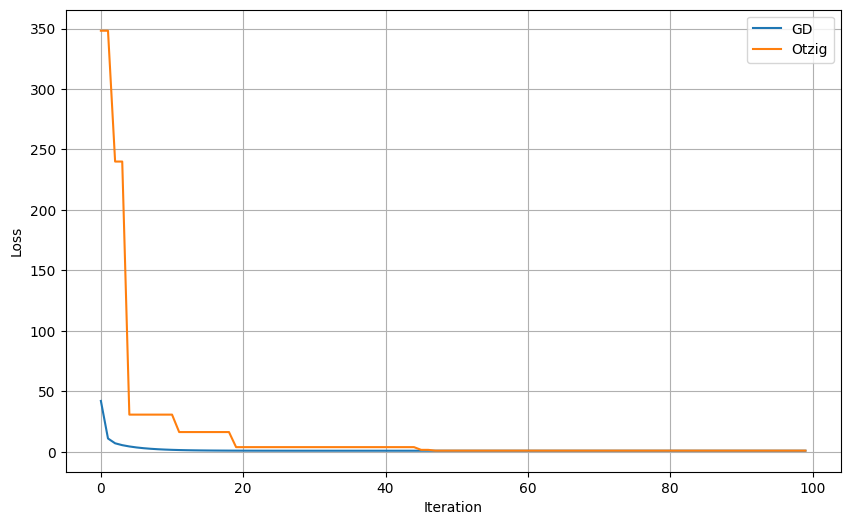

In [156]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.plot(gd_losses, label="GD")
plt.plot(otzig_losses, label="Otzig")

plt.xlabel("Iteration")
plt.ylabel("Loss")

plt.legend()
plt.grid()

plt.show()

Траектория достаточно хорошо идёт, но количества шагов не хватило

А с обычным градиентным спуском - они оба за 100 шагов хорошо справились, но обычный спуск чуть лучше